# Predictive / ML Analysis
FoodMatrix — Women in Data Datathon 2026 (Trade track)

Predicts `country_risk_score` and `risk_level` (Analysis 2's output) from the
underlying trade and supply features, using Random Forest and XGBoost.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats.mstats import winsorize
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from xgboost import XGBRegressor, XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

df = pd.read_csv("../data/processed/commodity_vulnerability.csv")
df.shape


(5807, 33)

## 2. Coverage

In [2]:
complete = df[df["country_risk_score"].notna()]
total_cy = df.groupby(["Area Code", "Year"]).ngroups
scored_cy = complete.groupby(["Area Code", "Year"]).ngroups

print(f"Scored country-years: {scored_cy} / {total_cy} ({scored_cy/total_cy:.1%})")
print(f"Countries with >=1 scored year: {complete['Area Code'].nunique()} / {df['Area Code'].nunique()}")


Scored country-years: 873 / 1940 (45.0%)
Countries with >=1 scored year: 88 / 168


## 3. Features

Only raw, pre-normalization inputs go in — `idr_norm`, `hhi_norm`,
`partner_count_norm` and `commodity_risk_score` are derived from the target
itself, so they're excluded.

In [3]:
order = ["Low", "Moderate", "High", "Very High"]

model_rows = df[df["country_risk_score"].notna()].copy()

raw_features = [
    "import_dependency_ratio", "partner_hhi", "partner_count", "top_partner_share",
    "kcal_per_capita_day", "protein_g_per_capita_day", "fat_g_per_capita_day",
    "self_sufficiency_ratio",
]

# raw import_dependency_ratio / self_sufficiency_ratio have a handful of extreme
# outliers (near-zero domestic supply as denominator) -- winsorize a modeling
# copy for stability, independent of the target
for col in raw_features:
    model_rows[col] = winsorize(model_rows[col].values, limits=[0.01, 0.01])

model_df = pd.get_dummies(model_rows, columns=["Commodity"], prefix="is")
commodity_cols = [c for c in model_df.columns if c.startswith("is_")]
feature_cols = raw_features + ["Year"] + commodity_cols

leak_cols = {"idr_norm", "hhi_norm", "partner_count_norm", "partner_count_risk", "commodity_risk_score"}
assert leak_cols.isdisjoint(feature_cols)

X = model_df[feature_cols]
y_reg = model_df["country_risk_score"]

le = LabelEncoder().fit(order)
y_clf = le.transform(model_df["risk_level"])

X.shape


(2619, 12)

## 4. Train/test split — temporal (train <=2020, test 2021-23)

In [4]:
train = model_df["Year"] <= 2020
test = model_df["Year"] > 2020

X_train, X_test = X[train], X[test]
y_reg_train, y_reg_test = y_reg[train], y_reg[test]
y_clf_train, y_clf_test = y_clf[train], y_clf[test]

len(X_train), len(X_test)


(1962, 657)

## 5. Regression — country_risk_score

In [5]:
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)
rf_reg.fit(X_train, y_reg_train)
rf_pred = rf_reg.predict(X_test)

xgb_reg = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=RANDOM_STATE)
xgb_reg.fit(X_train, y_reg_train)
xgb_pred = xgb_reg.predict(X_test)

def reg_report(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

pd.DataFrame([reg_report("Random Forest", y_reg_test, rf_pred), reg_report("XGBoost", y_reg_test, xgb_pred)])


,model,MAE,RMSE,R2
0,Random Forest,0.090505,0.121851,0.596213
1,XGBoost,0.081323,0.110532,0.667747


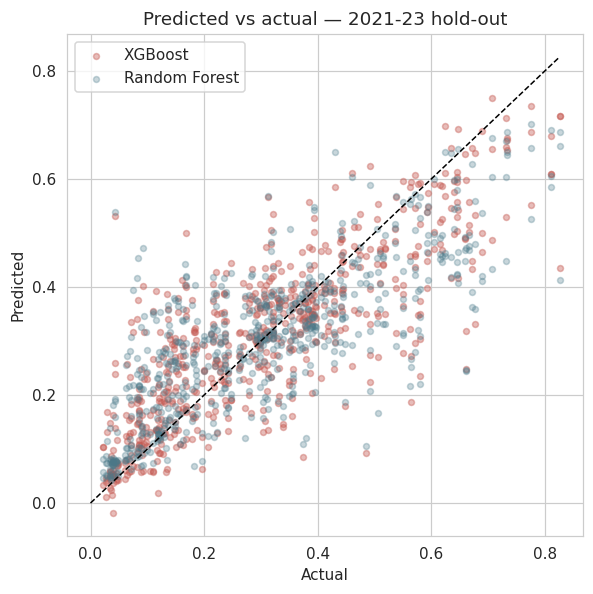

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_reg_test, xgb_pred, alpha=0.4, s=15, color="#c45850", label="XGBoost")
ax.scatter(y_reg_test, rf_pred, alpha=0.3, s=15, color="#4b7a8a", label="Random Forest")
lims = [0, max(y_reg_test.max(), xgb_pred.max(), rf_pred.max())]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs actual — 2021-23 hold-out")
ax.legend()
plt.tight_layout()
plt.savefig("regression_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Classification — risk_level

In [7]:
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_clf_train)
rf_clf_pred = rf_clf.predict(X_test)

xgb_clf = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                          random_state=RANDOM_STATE, eval_metric="mlogloss")
xgb_clf.fit(X_train, y_clf_train)
xgb_clf_pred = xgb_clf.predict(X_test)

def clf_report(name, y_true, y_pred):
    return {
        "model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro"),
    }

pd.DataFrame([clf_report("Random Forest", y_clf_test, rf_clf_pred), clf_report("XGBoost", y_clf_test, xgb_clf_pred)])


,model,Accuracy,F1 (macro)
0,Random Forest,0.712329,0.502156
1,XGBoost,0.735160,0.600109


              precision    recall  f1-score   support

        High       0.70      0.59      0.64       108
         Low       0.83      0.76      0.80       291
    Moderate       0.69      0.78      0.73       249
   Very High       0.18      0.33      0.23         9

    accuracy                           0.74       657
   macro avg       0.60      0.62      0.60       657
weighted avg       0.75      0.74      0.74       657



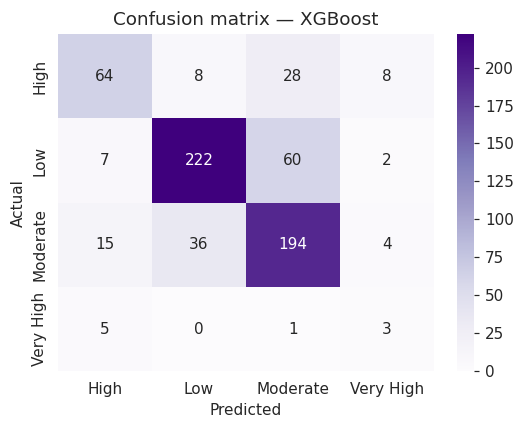

In [8]:
labels_present = sorted(set(y_clf_test) | set(xgb_clf_pred))
names_present = le.inverse_transform(labels_present)

print(classification_report(y_clf_test, xgb_clf_pred, labels=labels_present, target_names=names_present, zero_division=0))

cm = confusion_matrix(y_clf_test, xgb_clf_pred, labels=labels_present)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=names_present, yticklabels=names_present)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — XGBoost")
plt.tight_layout()
plt.savefig("classification_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Feature importance

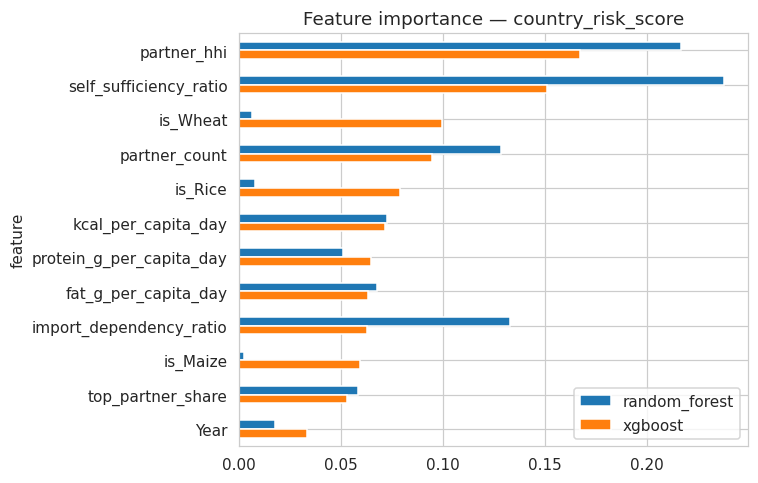

,feature,random_forest,xgboost
1,partner_hhi,0.216313,0.167252
7,self_sufficiency_ratio,0.237416,0.150869
11,is_Wheat,0.006554,0.099578
2,partner_count,0.128616,0.094716
10,is_Rice,0.007813,0.078835
4,kcal_per_capita_day,0.072808,0.071756
5,protein_g_per_capita_day,0.051204,0.064748
6,fat_g_per_capita_day,0.067526,0.063327
0,import_dependency_ratio,0.132909,0.062827
9,is_Maize,0.002715,0.059386


In [9]:
importances = pd.DataFrame({
    "feature": feature_cols,
    "random_forest": rf_reg.feature_importances_,
    "xgboost": xgb_reg.feature_importances_,
}).sort_values("xgboost", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
importances.set_index("feature")[["random_forest", "xgboost"]].plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title("Feature importance — country_risk_score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

importances


`self_sufficiency_ratio` and `partner_hhi` lead — concentration and
dependence drive the prediction, which matches Analysis 2's own logic
independently.

## 8. Export predictions

In [10]:
all_rows = model_df.drop_duplicates(["Area Code", "Year"])
all_X = all_rows[feature_cols]

export = all_rows[["Area Code", "Area_fbs", "Year", "country_risk_score", "risk_level"]].copy()
export["predicted_risk_score"] = xgb_reg.predict(all_X)
export["predicted_risk_level"] = le.inverse_transform(xgb_clf.predict(all_X))

export.to_csv("../data/processed/analysis3_predictions.csv", index=False)
export.head()


,Area Code,Area_fbs,Year,country_risk_score,risk_level,predicted_risk_score,predicted_risk_level
0,2,Afghanistan,2017,0.468027,Moderate,0.478404,Moderate
9,3,Albania,2010,0.406879,Moderate,0.384897,Moderate
10,3,Albania,2011,0.309420,Moderate,0.288731,Moderate
11,3,Albania,2012,0.456363,Moderate,0.344013,Moderate
12,3,Albania,2013,0.359904,Moderate,0.423004,Moderate


## Limitations

- Scored on 873/1940 country-years (45%) — same coverage constraint as Analysis 2
- Normalization is panel-wide within-commodity, not within-year
- "Very High" is a thin class (9 test rows) — its precision/recall is noisy
- Temporal split (train <=2020, test 2021-23) — deliberately stricter than a random split
